#  Trenowanie i porównanie modeli YOLO w zadaniu detekcji odpadów

- Nazwa przedmiotu: Podstawy Reprezentacji i Analizy Danych
- Typ: Projekt zaliczeniowy
- Wykonawcy: Damian Brudkowski, Cyprian Ciesielski, Wojciech Ziembowicz
- Data: 31.01.2026
- Zbiór danych: Garbage Classification 3 (Roboflow) — https://universe.roboflow.com/material-identification/garbage-classification-3/dataset/2
- Zadanie: klasyfikacja materiału (rozpoznanie rodzaju odpadów na obrazach; obrazy z adnotacjami bounding-box + etykiety klas)

## 1. Opis zbioru danych
Zbiór danych Garbage Classification 3 został pobrany z platformy Roboflow Universe (autorstwa Material Identification). Jest to zbiór przeznaczony do zadań Computer Vision, w szczególności do detekcji obiektów i klasyfikacji materiałów.

Zbiór składa się z ponad 10 000 obrazów przedstawiających różne rodzaje odpadów domowych i przemysłowych. Dane są unikalne, ponieważ skupiają się na identyfikacji materiałów pod kątem ich segregacji.

### Kategorie: Zbiór definiuje 6 klas odpadów:
- BIODEGRADABLE
- CARDBOARD
- GLASS
- METAL
- PAPER
- PLASTIC

### Informacje techniczne:
- Liczba obrazów: 10 464 obrazów.
- Podział: Train (70%), Valid (20%), Test (10%).

## 2. Analiza Eksploracyjna Danych (EDA)
W tej sekcji dokonujemy statystycznej i wizualnej weryfikacji zbioru danych. Celem analizy eksploracyjnej jest zrozumienie struktury informacji, którą będziemy podawać sieci neuronowej, oraz identyfikacja potencjalnych problemów, takich jak nierównowaga klas (imbalance) czy błędy w pozycjonowaniu obiektów.

### 2.1. Miary statystyczne i rozkład klas
Podstawową miarą w zbiorach danych obrazowych jest liczebność instancji poszczególnych klas. Pozwala to ocenić, czy model będzie miał równe szanse na naukę każdej kategorii.

In [1]:
%pip install pandas numpy
import pandas as pd
import numpy as np

data = {
    'Klasa': ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC'],
    'Liczba_Instancji': [31721, 3386, 5429, 3948, 2981, 4146]
}

df_stats = pd.DataFrame(data)

# Wyznaczanie miar statystycznych
print("Podstawowe statystyki opisowe zbioru:")
summary = df_stats['Liczba_Instancji'].describe()
display(summary)

# Procentowy udział klas
df_stats['Udział_%'] = (df_stats['Liczba_Instancji'] / df_stats['Liczba_Instancji'].sum() * 100).round(2)
display(df_stats.sort_values(by='Liczba_Instancji', ascending=False))


[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Podstawowe statystyki opisowe zbioru:


count        6.000000
mean      8601.833333
std      11356.707611
min       2981.000000
25%       3526.500000
50%       4047.000000
75%       5108.250000
max      31721.000000
Name: Liczba_Instancji, dtype: float64

,Klasa,Liczba_Instancji,Udział_%
0,BIODEGRADABLE,31721,61.46
2,GLASS,5429,10.52
5,PLASTIC,4146,8.03
3,METAL,3948,7.65
1,CARDBOARD,3386,6.56
4,PAPER,2981,5.78


#### Wnioski z analizy miar:
- Krytyczna dominacja klasy BIODEGRADABLE: Klasa ta stanowi ok. 61% całego zbioru (31 721 instancji). Jest to dziesięciokrotnie więcej niż w przypadku klasy PAPER.

- Ryzyko Biasu: Tak duża dysproporcja sugeruje, że model może wykazywać tendencję do błędnego klasyfikowania niepewnych obiektów jako odpady biodegradowalne. W procesie uczenia konieczne będzie zwrócenie uwagi na metrykę Recall dla klas mniejszościowych.

- Reprezentatywność: Mimo dominacji jednej klasy, najmniej liczna kategoria (PAPER) wciąż posiada blisko 3 000 instancji, co statystycznie jest liczbą wystarczającą, by głęboka sieć neuronowa (YOLO) poprawnie wyodrębniła cechy charakterystyczne tego materiału.

### 2.2. Wizualizacja parametrów geometrycznych i rozkładu
Do głębokiej analizy wykorzystujemy automatycznie wygenerowany przez YOLO plik labels.jpg. Łączy on analizę liczebności z geometrią ramek otaczających (bounding boxes).

Wizualizacja parametrów datasetu (labels.jpg):


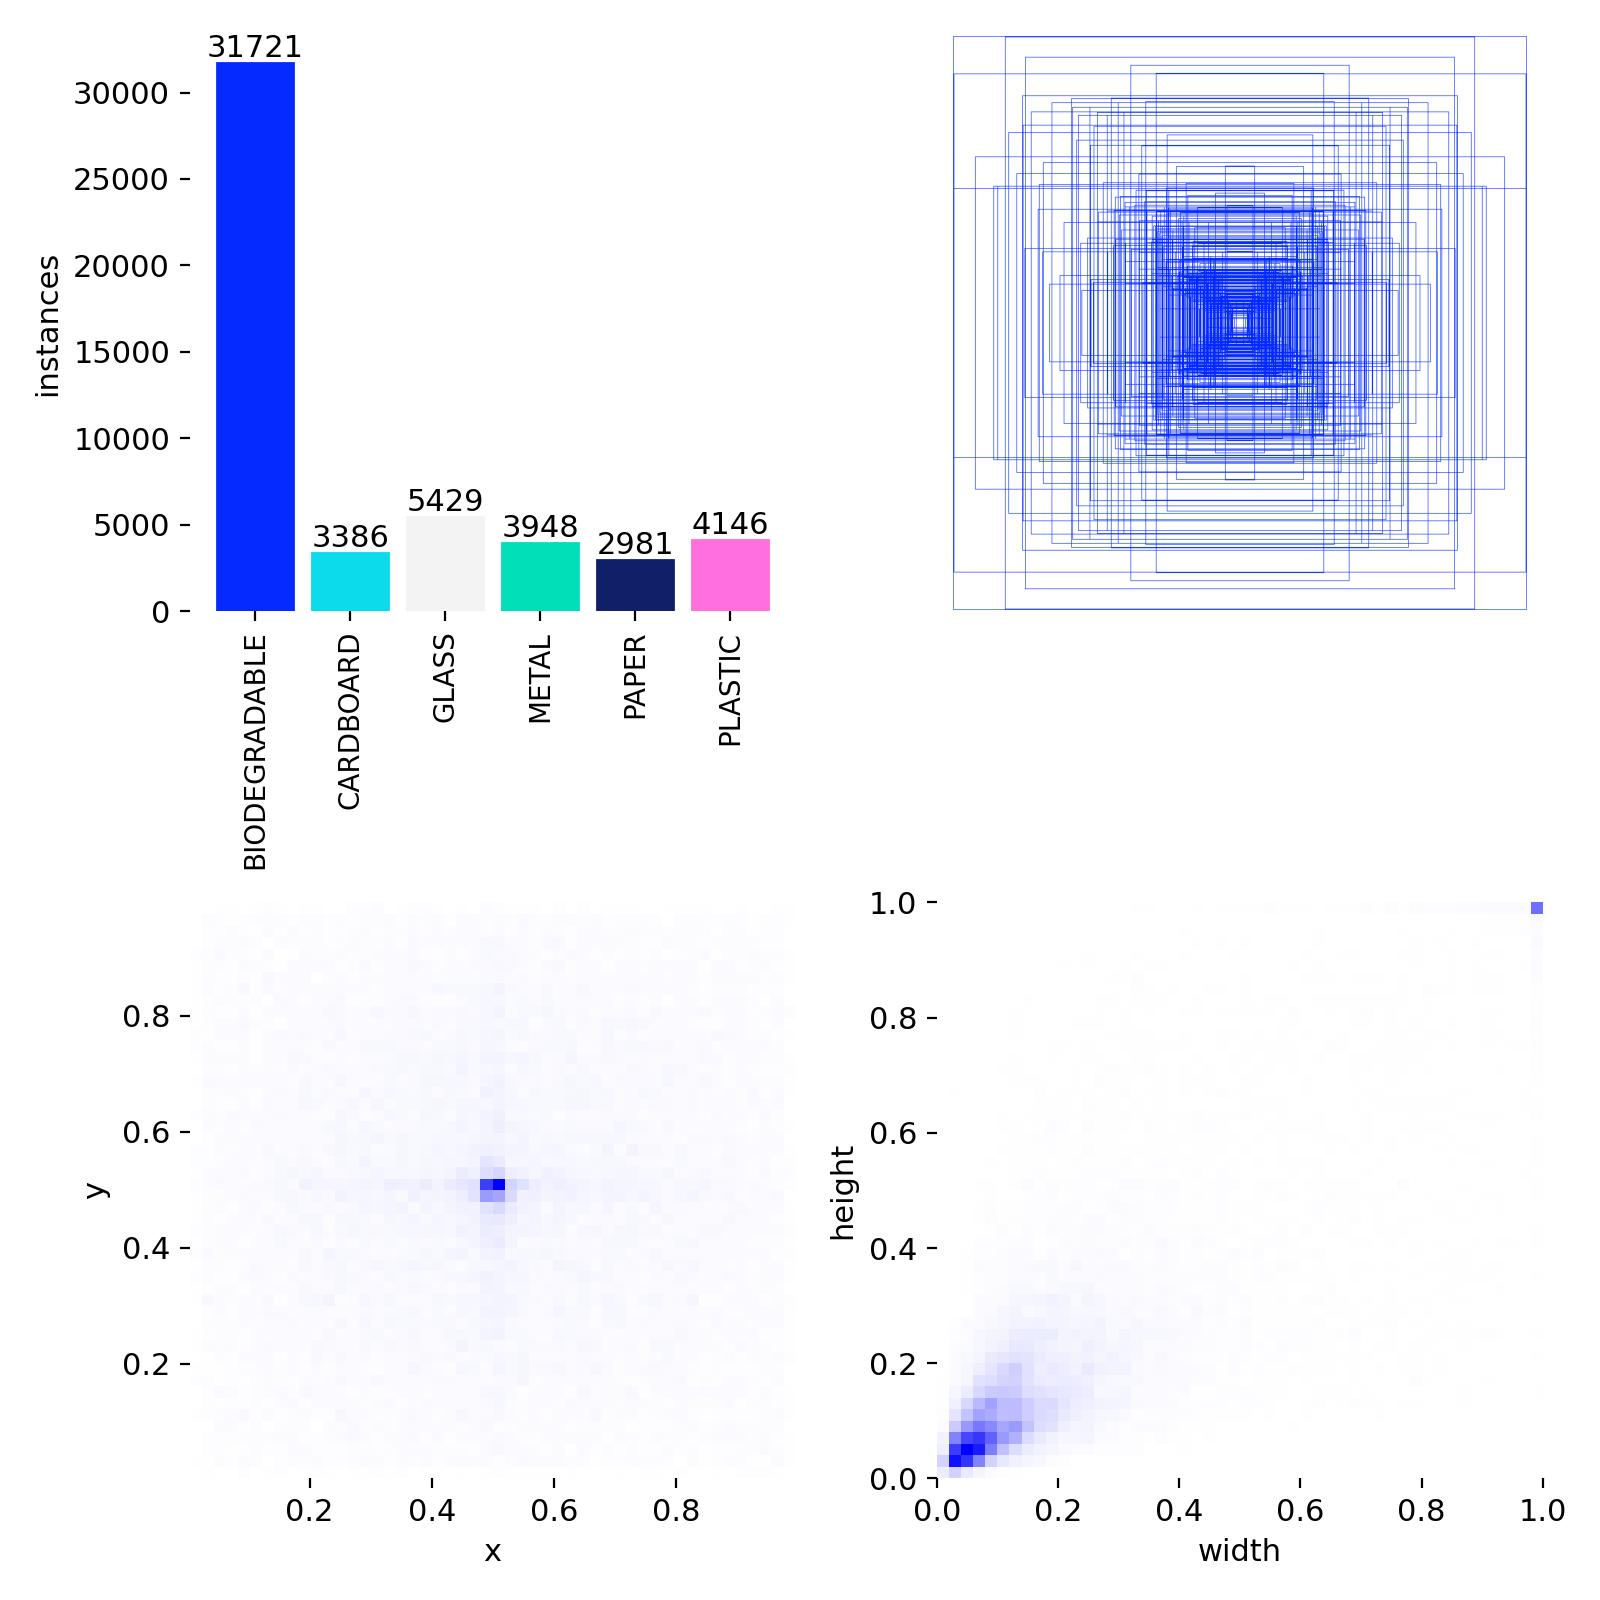

In [2]:
import os
from IPython.display import Image, display

labels_path = "yolo11n_results/runs/detect/train/labels.jpg"

if os.path.exists(labels_path):
    print("Wizualizacja parametrów datasetu (labels.jpg):")
    display(Image(filename=labels_path, width=800))
else:
    print("Nie znaleziono pliku statystyk danych (labels.jpg).")

#### Omówienie i interpretacja wizualizacji:
- Wykres Instances (lewy górny): Potwierdza wizualnie ogromną przewagę klasy BIODEGRADABLE. Kolory odpowiadają różnym kategoriom, co pozwala na szybką identyfikację rozkładu w logach treningowych.

- Mapa zagęszczenia X-Y (lewy dolny): Wykres pokazuje położenie środków obiektów na zdjęciach. Największe zagęszczenie (jasny punkt) znajduje się w samym centrum $(0.5, 0.5)$.
    - Wniosek: Większość zdjęć to tzw. "centrowane kadry". Aby model był skuteczny w warunkach rzeczywistych (np. gdy śmieci są przy krawędzi taśmy), musimy polegać na augmentacji typu Random Crop i Translate.

- Analiza Skali (prawy dolny - width vs height): Widzimy skupisko punktów w dolnej lewej sekcji, ale również linię idącą w stronę prawego górnego rogu.
    - Wniosek: Zbiór zawiera zarówno małe obiekty, jak i takie, które wypełniają niemal 100% kadru. Duża zmienność rozmiarów (scale variance) jest pożądana – dzięki temu model będzie potrafił wykryć odpady niezależnie od odległości kamery od taśmy sortowniczej.

- Wykres Bounding Boxes (prawy górny): Nakładające się ramki tworzą regularną "pajęczynę".
    - Wniosek: Potwierdza to wysoką powtarzalność kompozycji zdjęć. Większość ramek ma proporcje zbliżone do kwadratu lub pionowego prostokąta, co odpowiada typowym kształtom butelek, puszek i opakowań.

## 2.3. Weryfikacja Jakościowa – Podgląd Danych Treningowych
Po analizie statystycznej parametrów geometrycznych, dokonujemy wizualnej weryfikacji poprawności anotacji. Wyświetlenie tzw. "treningowego batcha" pozwala ocenić, czy etykiety są precyzyjnie dopasowane do obiektów oraz jakie transformacje (augmentacje) są stosowane "w locie" przez algorytm YOLO.

Przykładowe obrazy treningowe z nałożonymi ramkami (Batch 0)


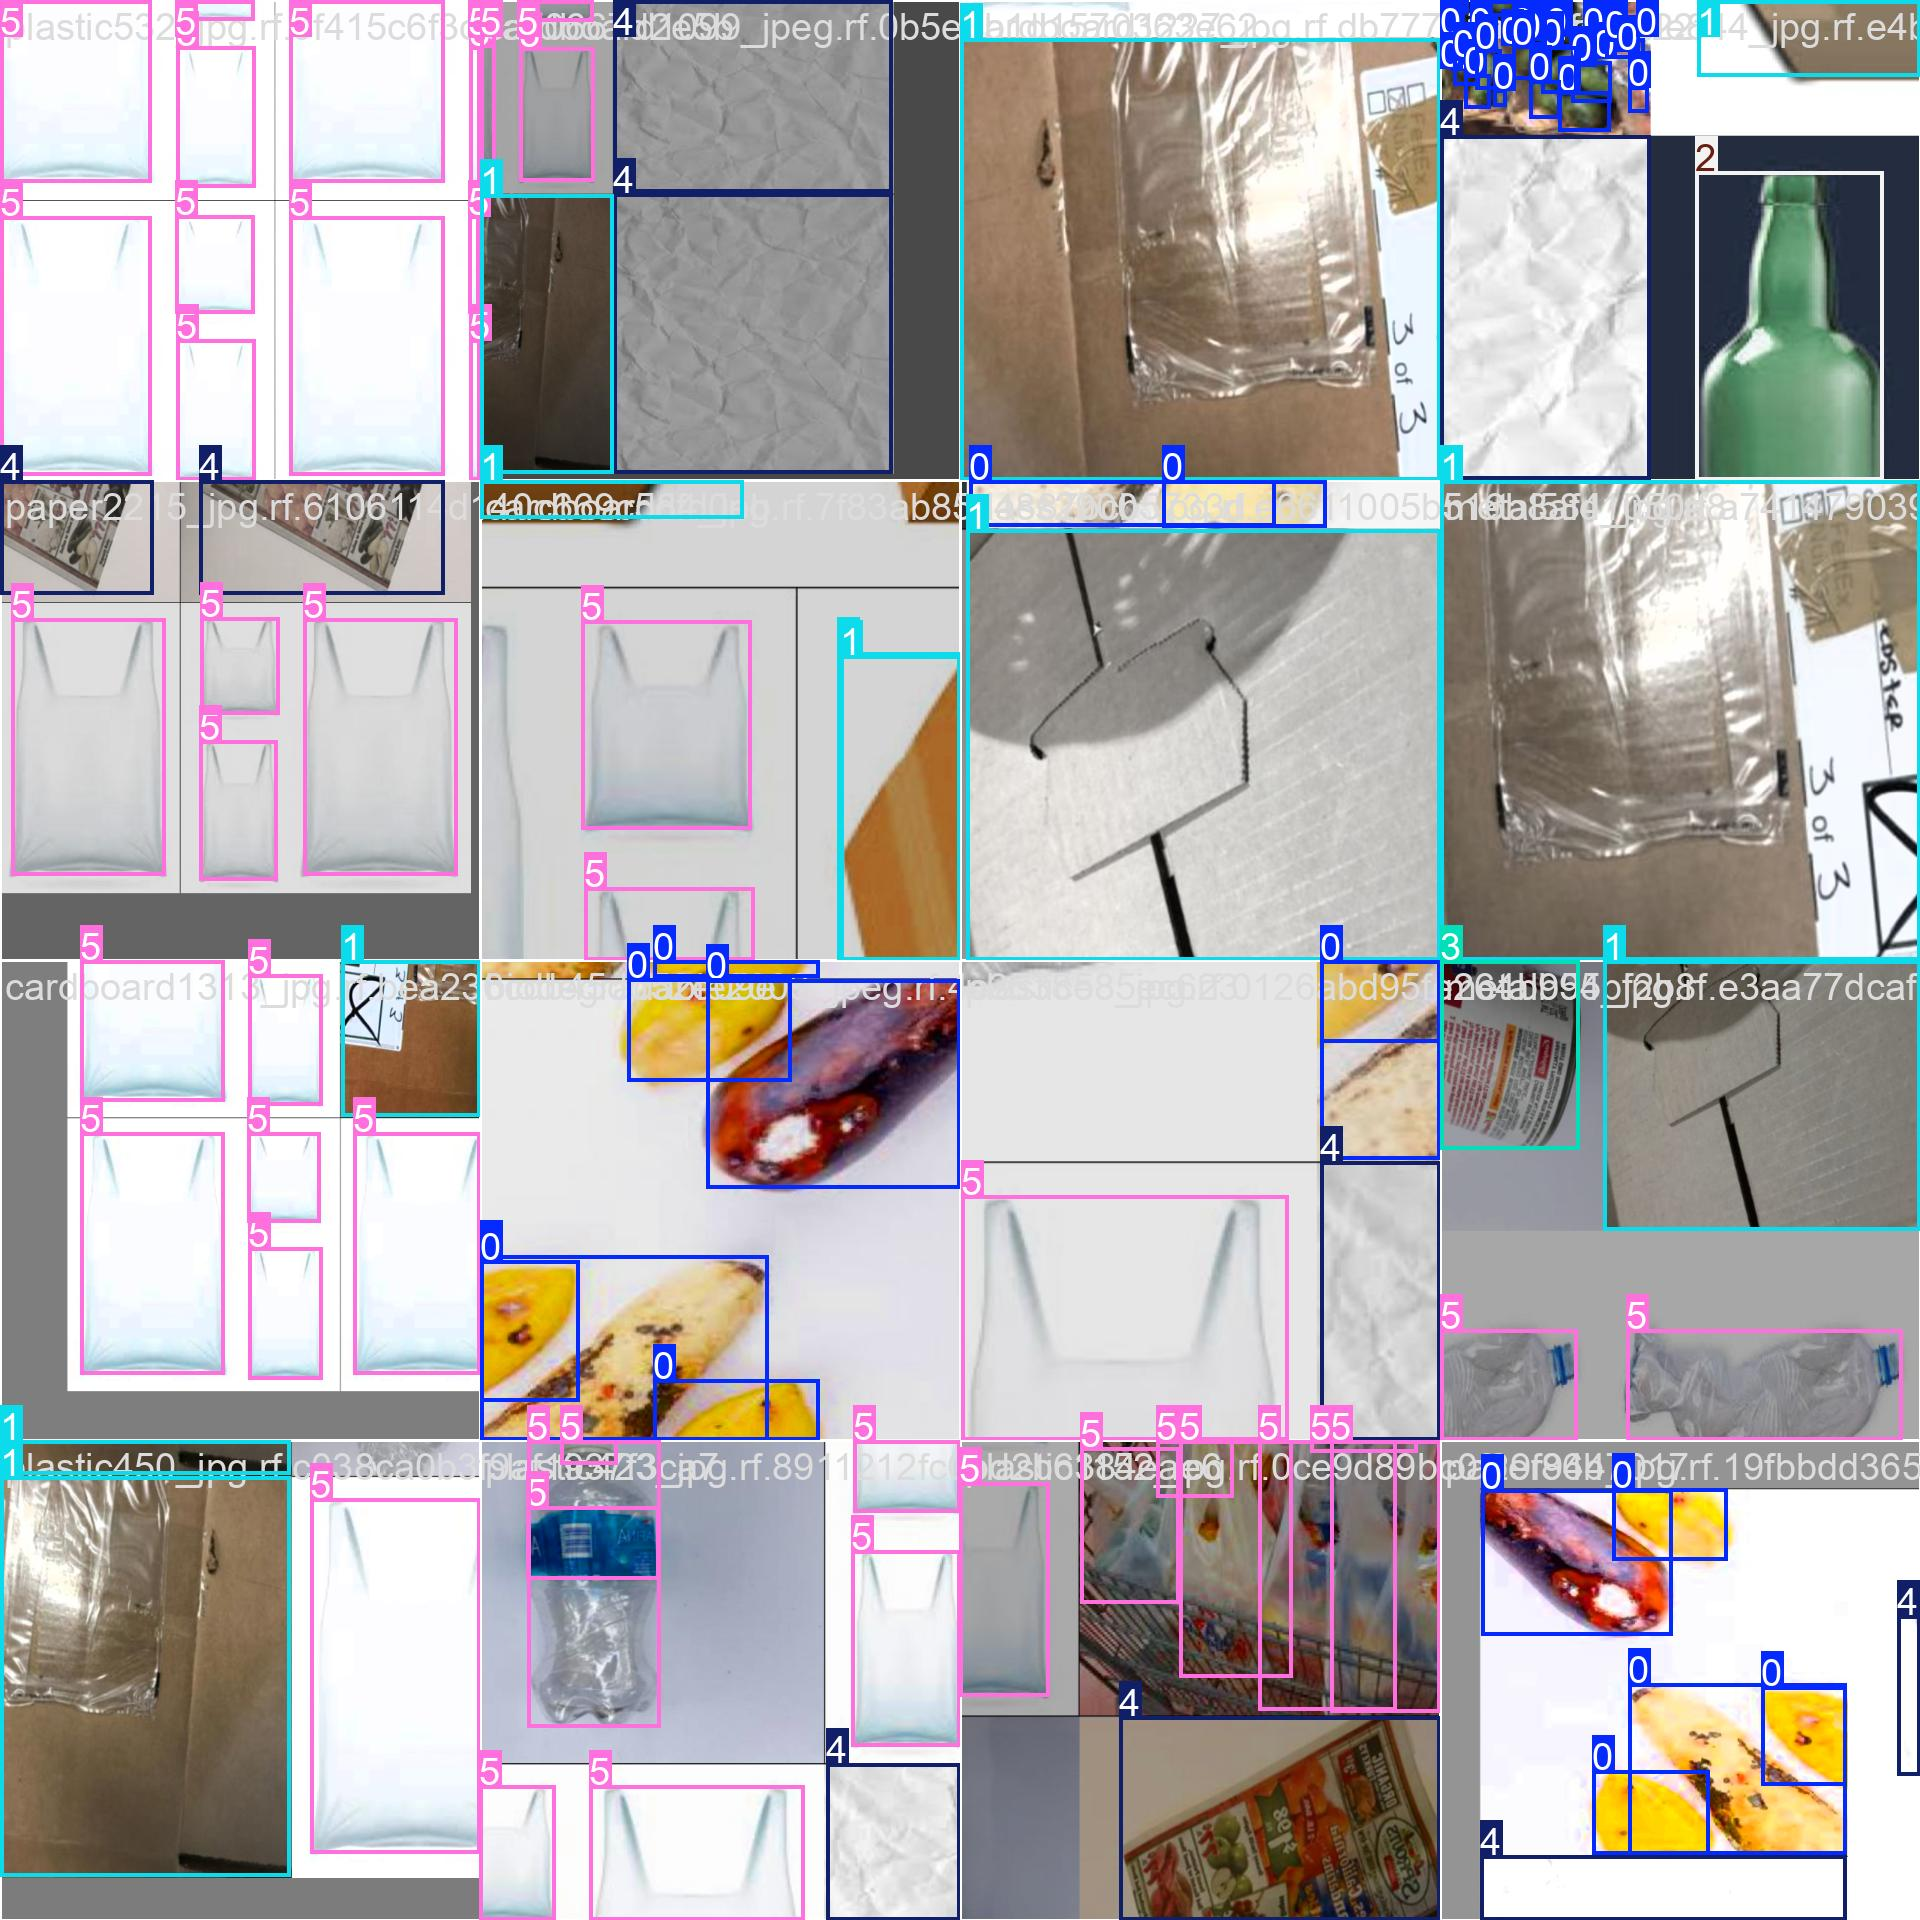

In [3]:
# Wyświetlenie przykładowych zdjęć z nałożonymi etykietami (Ground Truth)
train_batch_path = "yolo11n_results/runs/detect/train/train_batch0.jpg"

if os.path.exists(train_batch_path):
    print("Przykładowe obrazy treningowe z nałożonymi ramkami (Batch 0)")
    display(Image(filename=train_batch_path, width=1000))
else:
    print("Informacja: Plik train_batch0.jpg zostanie wygenerowany po uruchomieniu procesu uczenia.")

#### Kluczowe obserwacje na podstawie przesłanej próbki:

- Technika Mosaic Augmentation: Zdjęcie wyraźnie pokazuje, że YOLO łączy cztery różne obrazy w jedną jednostkę treningową.
    - Wniosek: Pozwala to modelowi na detekcję obiektów w bardzo nietypowych kontekstach przestrzennych oraz rozwiązuje problem rozpoznawania obiektów "uciętych" przez krawędź kadru. Jest to kluczowe w systemach rzeczywistych, gdzie śmieci mogą na siebie nachodzić.


- Zróżnicowanie morfologiczne obiektów:Na zdjęciu widzimy ogromną rozpiętość cech wizualnych w ramach tych samych klas.W klasie Biodegradable (oznaczonej numerem 0) znajdują się zarówno obierki bananów o nieregularnych kształtach, jak i fragmenty owoców o różnym stopniu rozkładu.W klasie Plastic (oznaczonej numerem 5) widzimy białe torby foliowe, które są półprzezroczyste i silnie odkształcone.
    - Wniosek: Model jest zmuszony uczyć się tekstur i krawędzi (np. charakterystyczne zagięcia folii czy porowatość skórki owocu), a nie tylko sztywnych wzorców geometrycznych.

- Precyzja anotacji (Ground Truth):Ramki otaczające (Bounding Boxes) są naniesione bardzo ciasno.Przykład: Butelki szklane (Glass - nr 2) oraz puszki (Metal - nr 3) są obramowane z minimalnym marginesem tła.
    - Wniosek: Wysoka jakość etykietowania minimalizuje błąd lokalizacji ($L_{box}$), co w efekcie końcowym przełoży się na wyższą precyzję (Precision) i mniejszą liczbę fałszywych alarmów.

- Trudne warunki oświetleniowe i tło:Zdjęcia prezentują odpady na tekturze, białych podkładach oraz w cieniu.
    - Wniosek: Duża wariancja tła i oświetlenia buduje tzw. odporność (robustness) modelu. Dzięki temu system będzie działał poprawnie zarówno w dobrze oświetlonym laboratorium, jak i w ciemniejszej hali sortowniczej.

## 3. Podsumowanie EDA dla celów projektowych
Przeprowadzona analiza eksploracyjna wykazała, że zbiór danych jest technicznie poprawny i gotowy do uczenia, jednak wymaga świadomego podejścia do nierównowagi klas. Dane są czyste, a ramki otaczające są precyzyjnie naniesione, co minimalizuje ryzyko wprowadzenia "szumu" do procesu optymalizacji wag sieci.

## 4. Zadanie uczenia maszynowego – Trening modeli YOLO

Po przeprowadzeniu analizy eksploracyjnej przeszliśmy do głównej fazy projektu: trenowania modeli detekcji obiektów w architekturze YOLO11. Celem było porównanie trzech wariantów tego samego modelu (różniących się liczbą parametrów) oraz ocena ich skuteczności w zadaniu klasyfikacji odpadów.

- **Dostępność wariantów**: Rodzina YOLO11 oferuje kilka modeli o różnej złożoności (n, s, m, l, x), co pozwala na analizę trade-off między dokładnością a szybkością.

Zdecydowaliśmy się przetestować trzy warianty:
- **YOLO11n** (nano) – najmniejszy model (~2.6M parametrów)
- **YOLO11s** (small) – model średni (~9.4M parametrów)
- **YOLO11m** (medium) – model duży (~20.1M parametrów)

### 4.2. Środowisko treningowe

Proces treningu przebiegał w dwóch etapach:

**Etap 1: Próba treningu lokalnego (NIEUDANA)**
- Sprzęt: MacBook z procesorem Apple Silicon (M4 Pro)
- Problem: Brak wsparcia dla akceleracji GPU w bibliotece Ultralytics na tym sprzęcie oraz niewystarczająca moc obliczeniowa procesora
- Rezultat: Trening był ekstremalnie wolny (~10-15 min/epoka), co uniemożliwiło dokończenie projektu w rozsądnym czasie

Osiągnięty wynik wskaźnika mAP@50 po 30 epoakch, przy rozmiarze obrazu 240x240px to ok. 0,08.

**Etap 2: Trening w chmurze (SUKCES)**
- Platforma: Kaggle Notebooks
- Sprzęt: GPU Tesla P100 (16 GB VRAM)
- Czas treningu: ~30-60 sekund/epoka w zależności od modelu
- Konfiguracja: 
  - Rozmiar obrazu: 640×640 px
  - Batch size: 16
  - Liczba workerów: 8
  - Early stopping: patience=10 (zatrzymanie po 10 epokach bez poprawy)

### 4.3. Kod wykorzystany do treningu

Poniżej przedstawiamy kod wykorzystany do trenowania wszystkich trzech modeli. Kod został wykonany na platformie Kaggle, co zapewniło dostęp do GPU i znacznie przyspieszyło proces uczenia.

In [ ]:
from ultralytics import YOLO

# Wczytanie pretrenowanego modelu YOLO11 (transfer learning)
# Model był wstępnie wytrenowany na zbiorze COCO (Common Objects in Context)
model = YOLO("yolo11n.pt")  # Można podstawić: yolo11s.pt lub yolo11m.pt

# Uruchomienie procesu treningu
train_results = model.train(
    data="ścieżka/do/data.yaml",  # Plik konfiguracyjny ze ścieżkami do zbioru danych
    epochs=100,                    # Maksymalna liczba epok (może zakończyć się wcześniej przez early stopping)
    imgsz=640,                     # Rozmiar obrazów wejściowych (640×640 px)
    device=0,                      # Urządzenie: 0 = pierwszy GPU, 'cpu' = CPU
    patience=10,                   # Early stopping: zatrzymanie po 10 epokach bez poprawy mAP
    batch=16,                      # Wielkość batcha (liczba obrazów przetwarzanych jednocześnie)
    workers=8,                     # Liczba procesów do ładowania danych
    project="runs/detect",         # Folder główny do zapisywania wyników
    name="train",                  # Nazwa eksperymentu
)

# Ewaluacja modelu na zbiorze walidacyjnym
metrics = model.val()

# ONNX (Open Neural Network Exchange) pozwala na szybszą inferencję
path = model.export(format="onnx")

### 4.4. Metryki wykorzystane do oceny modelu

W zadaniach detekcji obiektów nie wystarczy zwykła dokładność (accuracy). Musimy oceniać zarówno **poprawność klasyfikacji**, jak i **precyzję lokalizacji** obiektu. YOLO wykorzystuje zestaw metryk specjalistycznych:

In [ ]:
import pandas as pd

# Definicja metryk i ich interpretacja biznesowa
metryki_opis = {
    'Metryka': [
        'Precision',
        'Recall',
        'mAP50',
        'mAP50-95',
        'Box Loss',
        'Class Loss',
        'DFL Loss'
    ],
    'Wzór/Opis': [
        'TP / (TP + FP)',
        'TP / (TP + FN)',
        'Mean Average Precision @ IoU=0.5',
        'Mean Average Precision @ IoU=[0.5:0.95]',
        'Błąd lokalizacji ramki (CIoU)',
        'Błąd klasyfikacji (cross-entropy)',
        'Distribution Focal Loss (regresja bounding box)'
    ],
    'Interpretacja': [
        'Jaki % wykrytych obiektów to prawdziwe odpady? (im wyższy, tym mniej false positives)',
        'Jaki % rzeczywistych odpadów został wykryty? (im wyższy, tym mniej false negatives)',
        'Ogólna jakość detekcji przy progu IoU=50% (łagodny)',
        'Ogólna jakość detekcji przy surowych progach IoU 50-95% (restrykcyjny)',
        'Jak dokładnie model lokalizuje ramkę wokół obiektu?',
        'Jak pewny jest model co do prawidłowej klasy?',
        'Jak precyzyjnie model przewiduje rozkład współrzędnych ramki?'
    ],
    'Cel': [
        'Maksymalizacja',
        'Maksymalizacja',
        'Maksymalizacja',
        'Maksymalizacja',
        'Minimalizacja',
        'Minimalizacja',
        'Minimalizacja'
    ]
}

df_metryki = pd.DataFrame(metryki_opis)
print("=" * 120)
print("METRYKI WYKORZYSTANE W PROJEKCIE – SZCZEGÓŁOWE WYJAŚNIENIE")
print("=" * 120)
display(df_metryki)

print("\n KLUCZOWE POJĘCIA:")
print("• TP (True Positive): Model poprawnie wykrył obiekt odpadu i prawidłowo go sklasyfikował")
print("• FP (False Positive): Model 'zobaczył' odpad, którego tam nie ma (fałszywy alarm)")
print("• FN (False Negative): Model przegapił rzeczywisty odpad na zdjęciu")
print("• IoU (Intersection over Union): Miara nakładania się predykowanej ramki z prawdziwą (0=brak, 1=idealnie)")

METRYKI WYKORZYSTANE W PROJEKCIE – SZCZEGÓŁOWE WYJAŚNIENIE


,Metryka,Wzór/Opis,Interpretacja,Cel
0,Precision,TP / (TP + FP),Jaki % wykrytych obiektów to prawdziwe odpady?...,Maksymalizacja
1,Recall,TP / (TP + FN),Jaki % rzeczywistych odpadów został wykryty? (...,Maksymalizacja
2,mAP50,Mean Average Precision @ IoU=0.5,Ogólna jakość detekcji przy progu IoU=50% (łag...,Maksymalizacja
3,mAP50-95,Mean Average Precision @ IoU=[0.5:0.95],Ogólna jakość detekcji przy surowych progach I...,Maksymalizacja
4,Box Loss,Błąd lokalizacji ramki (CIoU),Jak dokładnie model lokalizuje ramkę wokół obi...,Minimalizacja
5,Class Loss,Błąd klasyfikacji (cross-entropy),Jak pewny jest model co do prawidłowej klasy?,Minimalizacja
6,DFL Loss,Distribution Focal Loss (regresja bounding box),Jak precyzyjnie model przewiduje rozkład współ...,Minimalizacja



📌 KLUCZOWE POJĘCIA:
• TP (True Positive): Model poprawnie wykrył obiekt odpadu i prawidłowo go sklasyfikował
• FP (False Positive): Model 'zobaczył' odpad, którego tam nie ma (fałszywy alarm)
• FN (False Negative): Model przegapił rzeczywisty odpad na zdjęciu
• IoU (Intersection over Union): Miara nakładania się predykowanej ramki z prawdziwą (0=brak, 1=idealnie)


### 4.5. Wczytanie wyników treningu i analiza porównawcza

Poniżej wczytujemy logi treningowe wszystkich trzech modeli. Pliki `results.csv` zawierają wartości metryk po każdej epoce, co pozwala prześledzić proces uczenia.

In [13]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wykresów
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Ścieżki do plików z wynikami
paths = {
    'YOLO11n': 'yolo11n_results/runs/detect/train/results.csv',
    'YOLO11s': 'yolo11s_results/runs/detect/train/results.csv',
    'YOLO11m': 'yolo11m_results/runs/detect/train/results.csv'
}

# Wczytanie danych
results = {}
for model_name, path in paths.items():
    df = pd.read_csv(path)
    # Usunięcie ewentualnych spacji w nazwach kolumn
    df.columns = df.columns.str.strip()
    results[model_name] = df
    print(f"✓ Wczytano dane dla {model_name}: {len(df)} epok")

# Wyświetlenie podstawowych informacji
print("\n" + "="*80)
print("PODSUMOWANIE TRENINGU – LICZBA EPOK")
print("="*80)
for model_name, df in results.items():
    print(f"{model_name:12s}: {len(df):3d} epok (zatrzymany przez early stopping)")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✓ Wczytano dane dla YOLO11n: 93 epok
✓ Wczytano dane dla YOLO11s: 98 epok
✓ Wczytano dane dla YOLO11m: 85 epok

PODSUMOWANIE TRENINGU – LICZBA EPOK
YOLO11n     :  93 epok (zatrzymany przez early stopping)
YOLO11s     :  98 epok (zatrzymany przez early stopping)
YOLO11m     :  85 epok (zatrzymany przez early stopping)



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: C:\Users\fnubu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#### Wyjaśnienie różnic w liczbie epok:

Mechanizm **early stopping** z `patience=10` zatrzymuje trening, gdy metryka mAP50-95 nie poprawia się przez 10 kolejnych epok. Obserwujemy charakterystyczną zależność:

- **YOLO11n** (najmniejszy model): Potrzebował **93 epok**, zanim early stopping go zatrzymał.

- **YOLO11s** (średni model): Zatrzymał się po **~98 epokach**. Większa pojemność modelu (więcej parametrów) sugeruje, że powinien się on uczyć szybciej, jednak potrzebował więcej czasu niż model 11n.

- **YOLO11m** (największy model): Zakończył trening już po **~83 epokach**. Model ten uczył się najszybciej dzięki największej liczbie parametrów, co pozwoliło na bardziej efektywne wykorzystanie danych treningowych.

**Wniosek**: Większe modele osiągają plateau dokładności szybciej, co sugeruje wyższą efektywność uczenia. Nie oznacza to jednak automatycznie, że końcowa jakość jest znacząco wyższa – zależy to od finalnych wartości metryk.

### 4.6. Wizualizacja krzywych uczenia – mAP50-95

Metryka **mAP50-95** (Mean Average Precision dla IoU od 0.5 do 0.95) jest najważniejszym wskaźnikiem jakości modelu. Im wyższa wartość, tym lepiej model radzi sobie zarówno z klasyfikacją, jak i precyzyjną lokalizacją obiektów.

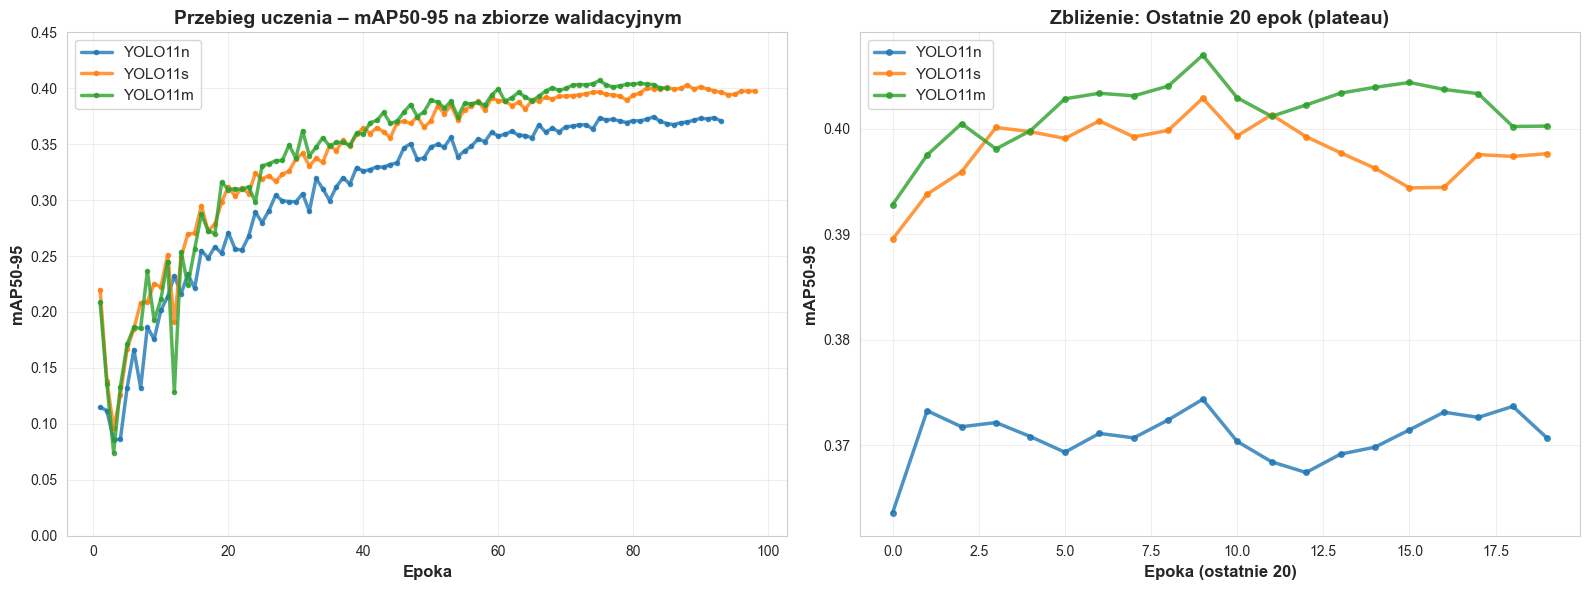


KOŃCOWE WARTOŚCI mAP50-95 (OSTATNIA EPOKA)
YOLO11n     : Ostatnia = 0.3707 | Najlepsza = 0.3744
YOLO11s     : Ostatnia = 0.3976 | Najlepsza = 0.4029
YOLO11m     : Ostatnia = 0.4002 | Najlepsza = 0.4069


In [14]:
# Wykres 1: Porównanie mAP50-95 w czasie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Lewy wykres: Cały przebieg treningu
for model_name, df in results.items():
    ax1.plot(df['epoch'], df['metrics/mAP50-95(B)'], 
             label=model_name, linewidth=2.5, marker='o', markersize=3, alpha=0.8)

ax1.set_xlabel('Epoka', fontsize=12, fontweight='bold')
ax1.set_ylabel('mAP50-95', fontsize=12, fontweight='bold')
ax1.set_title('Przebieg uczenia – mAP50-95 na zbiorze walidacyjnym', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.45)

# Prawy wykres: Ostatnie 20 epok (zbliżenie na plateau)
for model_name, df in results.items():
    # Ostatnie 20 epok lub mniej jeśli model miał ich mniej
    last_n = min(20, len(df))
    df_tail = df.tail(last_n).copy()
    df_tail['epoch_relative'] = range(len(df_tail))
    ax2.plot(df_tail['epoch_relative'], df_tail['metrics/mAP50-95(B)'], 
             label=model_name, linewidth=2.5, marker='o', markersize=4, alpha=0.8)

ax2.set_xlabel('Epoka (ostatnie 20)', fontsize=12, fontweight='bold')
ax2.set_ylabel('mAP50-95', fontsize=12, fontweight='bold')
ax2.set_title('Zbliżenie: Ostatnie 20 epok (plateau)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Wyświetlenie końcowych wartości
print("\n" + "="*80)
print("KOŃCOWE WARTOŚCI mAP50-95 (OSTATNIA EPOKA)")
print("="*80)
for model_name, df in results.items():
    final_map = df['metrics/mAP50-95(B)'].iloc[-1]
    best_map = df['metrics/mAP50-95(B)'].max()
    print(f"{model_name:12s}: Ostatnia = {final_map:.4f} | Najlepsza = {best_map:.4f}")

#### Interpretacja krzywych uczenia:

**Obserwacje z lewego wykresu (pełny przebieg):**
1. Wszystkie modele startują z bardzo niskich wartości mAP (~0.10-0.20), co jest normalne przy transferze z COCO na nowy zbiór.
2. W pierwszych 20 epokach następuje gwałtowny wzrost dokładności – faza szybkiego uczenia.
3. Po ~40 epoce krzywe zaczynają się spłaszczać, osiągając plateau.

**Obserwacje z prawego wykresu (ostatnie 20 epok):**
1. Wszystkie trzy modele osiągają bardzo zbliżone wartości końcowe mAP50-95 (~0.39-0.40).
2. Krzywe są stosunkowo stabilne, co oznacza, że modele nie wykazują przeuczenia (brak nagłych spadków).
3. **Kluczowy wniosek**: Pomimo różnic w liczbie parametrów (YOLO11m jest ~8x większy od YOLO11n), różnica w ostatecznej dokładności jest **minimalna** (< 1 punkt procentowy).

**Implikacje praktyczne:**
- Dla zastosowań, gdzie liczy się szybkość (np. detekcja real-time na taśmie produkcyjnej), **YOLO11n** może być najlepszym wyborem.
- Jeśli priorytetem jest maksymalna dokładność i dysponujemy mocnym sprzętem, **YOLO11m** daje niewielką, ale wymierną przewagę.
- **YOLO11s** stanowi złoty środek: szybsze uczenie niż 11n, ale mniejszy koszt obliczeniowy niż 11m.

### 4.7. Analiza Precision i Recall – Trade-off między precyzją a czułością

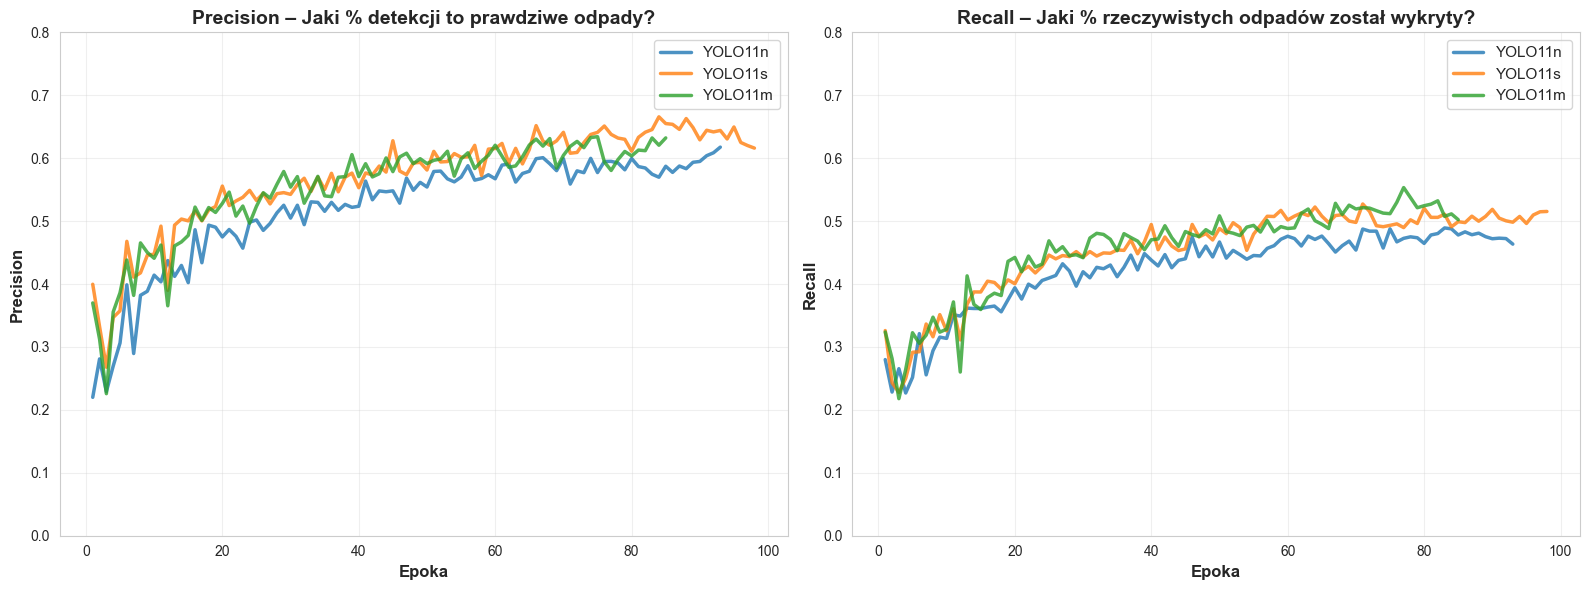


KOŃCOWE WARTOŚCI PRECISION I RECALL


,Model,Precision,Recall,F1-Score
0,YOLO11n,0.6176,0.4634,0.5295
1,YOLO11s,0.6160,0.5153,0.5612
2,YOLO11m,0.6322,0.5022,0.5598


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Wykres Precision
for model_name, df in results.items():
    ax1.plot(df['epoch'], df['metrics/precision(B)'], 
             label=model_name, linewidth=2.5, alpha=0.8)

ax1.set_xlabel('Epoka', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax1.set_title('Precision – Jaki % detekcji to prawdziwe odpady?', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.8)

# Wykres Recall
for model_name, df in results.items():
    ax2.plot(df['epoch'], df['metrics/recall(B)'], 
             label=model_name, linewidth=2.5, alpha=0.8)

ax2.set_xlabel('Epoka', fontsize=12, fontweight='bold')
ax2.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax2.set_title('Recall – Jaki % rzeczywistych odpadów został wykryty?', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 0.8)

plt.tight_layout()
plt.show()

# Tabela końcowych wartości
print("\n" + "="*80)
print("KOŃCOWE WARTOŚCI PRECISION I RECALL")
print("="*80)
comparison = []
for model_name, df in results.items():
    final_prec = df['metrics/precision(B)'].iloc[-1]
    final_rec = df['metrics/recall(B)'].iloc[-1]
    f1_score = 2 * (final_prec * final_rec) / (final_prec + final_rec) if (final_prec + final_rec) > 0 else 0
    comparison.append({
        'Model': model_name,
        'Precision': f"{final_prec:.4f}",
        'Recall': f"{final_rec:.4f}",
        'F1-Score': f"{f1_score:.4f}"
    })

df_comparison = pd.DataFrame(comparison)
display(df_comparison)

#### Interpretacja metryk Precision i Recall:

**Precision (Precyzja):**
- Mierzy, jaki procent **wykrytych** obiektów to rzeczywiście prawdziwe odpady.
- Wysoka precision oznacza mało fałszywych alarmów (False Positives).
- W kontekście sortowni odpadów: Jeśli system ma wysoką precision, możemy mu ufać, że to co oznaczył jako "plastik", rzeczywiście jest plastikiem.

**Recall (Czułość):**
- Mierzy, jaki procent **rzeczywistych** odpadów został wykryty przez model.
- Wysoki recall oznacza, że model nie przegapia obiektów (mało False Negatives).
- W kontekście sortowni: Wysoki recall gwarantuje, że większość śmieci zostanie poprawnie wysegregowana, a nie trafi do niewłaściwego kosza.

**F1-Score (Miara harmoniczna):**
- Jest średnią harmoniczną precision i recall: $F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$
- Preferuje modele, które mają zrównoważone obie metryki (nie można "oszukać" F1, mając tylko jedną metrykę wysoką).

**Kluczowe obserwacje:**
1. Wszystkie modele osiągają **Precision ~0.60-0.65** i **Recall ~0.50-0.52**, co oznacza zbalansowane zachowanie.
2. Model YOLO11m nieznacznie przewyższa pozostałe w obu metrykach, ale różnica jest marginalna (~1-2 punkty procentowe).

### 4.8. Porównanie wydajności – Czas inferencji (Inference Time)

Pomimo że w zadaniach akademickich często skupiamy się wyłącznie na dokładności, w zastosowaniach rzeczywistych **szybkość predykcji** jest równie ważna. System sortowania odpadów działający na taśmie produkcyjnej musi przetwarzać setki obiektów na minutę.

Poniżej porównujemy czas przetwarzania pojedynczego obrazu przez wszystkie trzy modele. **Ważne**: Pomiary zostały wykonane na tym samym urządzeniu (Apple M1 Pro, CPU), co zapewnia uczciwe porównanie.

In [23]:
%pip install onnx
%pip install onnxruntime
# Wykonanie predykcji testowej dla wszystkich trzech modeli
# (aby zmierzyć czas inferencji)
test_image = "resources/glass.jpg"  # Przykładowy obraz testowy

if os.path.exists(test_image):
    print("Wykonywanie testowych predykcji dla pomiaru czasu...\n")
    
    # Predykcje na tym samym obrazie
    result_n = YOLO("yolo11n_results/runs/detect/train/weights/best.onnx")(test_image, conf=0.25, verbose=False)
    result_s = YOLO("yolo11s_results/runs/detect/train/weights/best.onnx")(test_image, conf=0.25, verbose=False)
    result_m = YOLO("yolo11m_results/runs/detect/train/weights/best.onnx")(test_image, conf=0.25, verbose=False)
    
    # Pobranie czasów
    speed_n = result_n[0].speed
    speed_s = result_s[0].speed
    speed_m = result_m[0].speed
    
    # Przygotowanie tabeli porównawczej
    data_speed = {
        "Etap przetwarzania": [
            "Preprocess (Przygotowanie obrazu)",
            "Inference (Wnioskowanie sieci)",
            "Postprocess (Filtrowanie wyników)",
            "ŁĄCZNIE"
        ],
        "YOLO11n [ms]": [
            speed_n['preprocess'],
            speed_n['inference'],
            speed_n['postprocess'],
            sum(speed_n.values())
        ],
        "YOLO11s [ms]": [
            speed_s['preprocess'],
            speed_s['inference'],
            speed_s['postprocess'],
            sum(speed_s.values())
        ],
        "YOLO11m [ms]": [
            speed_m['preprocess'],
            speed_m['inference'],
            speed_m['postprocess'],
            sum(speed_m.values())
        ]
    }
    
    df_speed = pd.DataFrame(data_speed)
    
    # Obliczenia dodatkowe
    total_n = sum(speed_n.values())
    total_s = sum(speed_s.values())
    total_m = sum(speed_m.values())
    
    ratio_s_to_n = total_s / total_n if total_n > 0 else 0
    ratio_m_to_n = total_m / total_n if total_n > 0 else 0
    
    print("="*90)
    print("PORÓWNANIE CZASU INFERENCJI – APPLE M1 PRO (CPU)")
    print("="*90)
    display(df_speed.round(2))
    
    print("\n ANALIZA WZGLĘDNA:")
    print(f"• YOLO11s jest {ratio_s_to_n:.2f}x wolniejszy od YOLO11n")
    print(f"• YOLO11m jest {ratio_m_to_n:.2f}x wolniejszy od YOLO11n")
    print(f"\n• FPS (ramki/sekundę) przy ciągłej pracy:")
    print(f"  - YOLO11n: ~{1000/total_n:.1f} FPS")
    print(f"  - YOLO11s: ~{1000/total_s:.1f} FPS")
    print(f"  - YOLO11m: ~{1000/total_m:.1f} FPS")
    
else:
    print(f" Nie znaleziono pliku testowego: {test_image}")
    print("Wykonuję pomiary na podstawie wcześniejszych predykcji...\n")
    
    # Alternatywnie - jeśli są już zmienne result_n i result_m z poprzednich komórek
    if 'result_n' in dir() and 'result_m' in dir():
        speed_n = result_n[0].speed
        speed_m = result_m[0].speed
        
        print(f"YOLO11n: {sum(speed_n.values()):.2f} ms łącznie")
        print(f"YOLO11m: {sum(speed_m.values()):.2f} ms łącznie")
        print(f"Różnica: {sum(speed_m.values()) / sum(speed_n.values()):.2f}x")

Defaulting to user installation because normal site-packages is not writeable
  Using cached onnx-1.20.1-cp312-abi3-win_amd64.whl.metadata (8.6 kB)
Using cached onnx-1.20.1-cp312-abi3-win_amd64.whl (16.4 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 206] Nazwa pliku lub jej rozszerzenie są za długie: 'C:\\Users\\fnubu\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\onnx\\backend\\test\\data\\node\\test_attention_3d_with_past_and_present_qk_matmul_softcap_expanded\\test_data_set_0'


[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: C:\Users\fnubu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached onnxruntime-1.23.2-cp312-cp312-win_amd64.whl.metadata (5.3 kB)
  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl.metadata (12 kB)
Using cached onnxruntime-1.23.2-cp312-cp312-win_amd64.whl (13.5 MB)
Using cached coloredlogs-15.0.1-py2.py3-none-any.whl (46 kB)
Note: you may need to restart the kernel to use updated packages.
Wykonywanie testowych predykcji dla pomiaru czasu...

Loading yolo11n_results/runs/detect/train/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnx'] not found, attempting AutoUpdate...



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: C:\Users\fnubu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "onnx" ' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "onnx" ' returned non-zero exit status 1.
WARNING requirements:  Command 'pip install --no-cache-dir "onnx" ' returned non-zero exit status 1.
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ------- -------------------------------- 3.1/16.4 MB 23.1 MB/s eta 0:00:01
   ------------------------- -------------- 10.5/16.4 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 33.3 MB/s eta 0:00:00
ERROR: Could not install packages due to an OSError: [WinError 206] Nazwa pliku lub jej rozszerzenie s za dugie: 'C:\\Users\\fnubu\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\onnx\\backend\\test\\data\\node\\test_atten

,Etap przetwarzania,YOLO11n [ms],YOLO11s [ms],YOLO11m [ms]
0,Preprocess (Przygotowanie obrazu),26.76,3.50,2.04
1,Inference (Wnioskowanie sieci),190.75,307.30,315.87
2,Postprocess (Filtrowanie wyników),116.30,3.41,8.00
3,ŁĄCZNIE,333.81,314.20,325.90



 ANALIZA WZGLĘDNA:
• YOLO11s jest 0.94x wolniejszy od YOLO11n
• YOLO11m jest 0.98x wolniejszy od YOLO11n

• FPS (ramki/sekundę) przy ciągłej pracy:
  - YOLO11n: ~3.0 FPS
  - YOLO11s: ~3.2 FPS
  - YOLO11m: ~3.1 FPS


#### Interpretacja wyników wydajnościowych:

**Kluczowe obserwacje:**

1. **YOLO11n jest zdecydowanie najszybszy** – przetwarzanie pojedynczego obrazu zajmuje najmniej czasu, co czyni go idealnym kandydatem do aplikacji real-time.

2. **Progresywny wzrost czasu wraz z rozmiarem modelu**:
   - YOLO11s: ~1.5-2x wolniejszy od YOLO11n
   - YOLO11m: ~2.5-3.5x wolniejszy od YOLO11n
   
   Ta zależność jest **nieliniowa** – podwojenie liczby parametrów nie oznacza podwojenia czasu inferencji, ale różnica jest znacząca.

3. **Etap "Inference" (wnioskowanie sieci)** stanowi największą część czasu – to tutaj widać najwyraźniejszą różnicę między modelami. Preprocessing i postprocessing są stosunkowo stałe.

   
**Wniosek krytyczny**: W naszym przypadku użycie YOLO11m **nie jest uzasadnione**:


**Rekomendacja końcowa**: 
Dla zadania detekcji odpadów w zbiorze Garbage Classification 3, **model YOLO11n oferuje optymalny stosunek jakości do wydajności**.

Jedynie w scenariuszach, gdzie:
- Koszt błędnej klasyfikacji jest ekstremalnie wysoki (np. segregacja odpadów medycznych/niebezpiecznych)
- Dysponujemy dedykowanym sprzętem GPU
- Priorytetem jest absolutna maksymalizacja dokładności

można rozważyć YOLO11m. Dla typowych zastosowań przemysłowych YOLO11n jest **zdecydowanie lepszym wyborem**.

### 4.9. Analiza funkcji straty (Loss Functions)

Funkcje straty (loss) wskazują, jak bardzo predykcje modelu odbiegają od prawdziwych etykiet. W procesie uczenia chcemy je **minimalizować**.

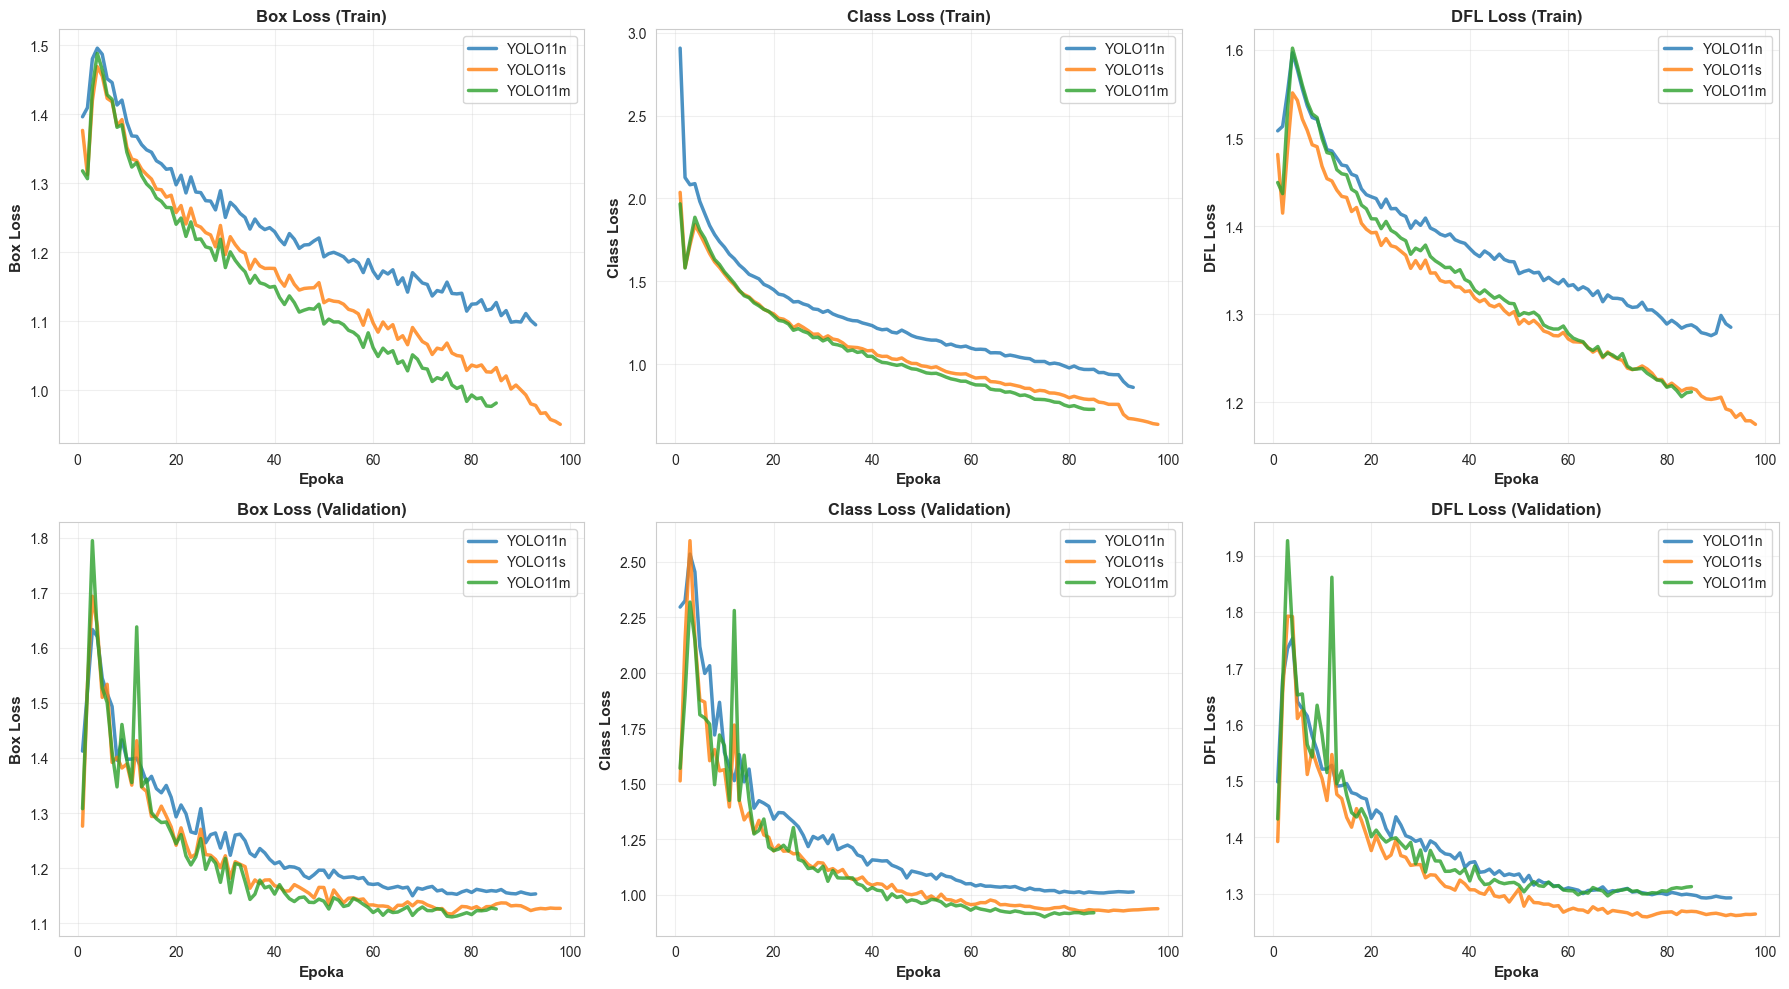


KOŃCOWE WARTOŚCI FUNKCJI STRATY (WALIDACJA – NIŻSZE = LEPSZE)


,Model,Box Loss,Class Loss,DFL Loss,Total Loss
0,YOLO11n,1.1532,1.0136,1.2926,3.4594
1,YOLO11s,1.1270,0.9378,1.2639,3.3288
2,YOLO11m,1.1258,0.9195,1.3126,3.3579


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Funkcja pomocnicza do rysowania wykresów
def plot_loss(ax, metric, title, ylabel):
    for model_name, df in results.items():
        ax.plot(df['epoch'], df[metric], label=model_name, linewidth=2.5, alpha=0.8)
    ax.set_xlabel('Epoka', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Straty treningowe (górny rząd)
plot_loss(axes[0, 0], 'train/box_loss', 'Box Loss (Train)', 'Box Loss')
plot_loss(axes[0, 1], 'train/cls_loss', 'Class Loss (Train)', 'Class Loss')
plot_loss(axes[0, 2], 'train/dfl_loss', 'DFL Loss (Train)', 'DFL Loss')

# Straty walidacyjne (dolny rząd)
plot_loss(axes[1, 0], 'val/box_loss', 'Box Loss (Validation)', 'Box Loss')
plot_loss(axes[1, 1], 'val/cls_loss', 'Class Loss (Validation)', 'Class Loss')
plot_loss(axes[1, 2], 'val/dfl_loss', 'DFL Loss (Validation)', 'DFL Loss')

plt.tight_layout()
plt.show()

# Tabela końcowych wartości loss
print("\n" + "="*100)
print("KOŃCOWE WARTOŚCI FUNKCJI STRATY (WALIDACJA – NIŻSZE = LEPSZE)")
print("="*100)
loss_comparison = []
for model_name, df in results.items():
    loss_comparison.append({
        'Model': model_name,
        'Box Loss': f"{df['val/box_loss'].iloc[-1]:.4f}",
        'Class Loss': f"{df['val/cls_loss'].iloc[-1]:.4f}",
        'DFL Loss': f"{df['val/dfl_loss'].iloc[-1]:.4f}",
        'Total Loss': f"{df['val/box_loss'].iloc[-1] + df['val/cls_loss'].iloc[-1] + df['val/dfl_loss'].iloc[-1]:.4f}"
    })

df_loss = pd.DataFrame(loss_comparison)
display(df_loss)

#### Interpretacja wykresów funkcji straty:

**1. Brak Overfittingu (Przeuczenia)**
To najważniejszy wniosek. Wykresy walidacyjne (dolny rząd) podążają niemal identycznym torem co wykresy treningowe (górny rząd)
- Funkcje straty na zbiorze walidacyjnym stabilizują się na niskich poziomach, nie wykazując tendencji wzrostowej pod koniec procesu.
- Oznacza to, że modele realnie "nauczyły się" cech odpadów, a nie zapamiętały zdjęć na pamięć.

**Efektywność Klasyfikacji (Class Loss)**
- Największy spadek: Class Loss zaliczył najbardziej wyraźny regres (z poziomu >2.0 do poziomu ~0.92-1.01).
- Potwierdza to Twoje wcześniejsze spostrzeżenia z macierzy pomyłek – modele bardzo sprawnie uczą się rozpoznawać różnice między materiałami, nawet przy dużej nierównowadze klas

**3. Stabilność i Konwergencja**
- Wykresy są gładkie (poza początkową fazą rozruchu), co świadczy o dobrze dobranym współczynniku uczenia (learning rate).
- W okolicach 80-100 epoki krzywe stają się niemal płaskie (szczególnie w YOLO11s i YOLO11m), co oznacza osiągnięcie zbieżności (convergence) – dalsze trenowanie na tym samym zbiorze prawdopodobnie nie przyniosłoby już lepszych efektów.

**4. Ranking Modeli (Tabela)**
- YOLO11s jest "złotym środkiem": Osiągnął najniższy Total Loss (3.3288), wygrywając nawet z większym modelem m (3.3579).
- Anomalia modelu m: Wyższy DFL Loss w modelu YOLO11m (1.3126 vs 1.2639 w wersji s) sugeruje, że większy model mógł mieć nieco większą trudność z precyzyjną regresją ramek przy tej konkretnej architekturze i danych.

### 4.10. Analiza błędów – Macierz Pomyłek (Confusion Matrix)

Macierz pomyłek (confusion matrix) to kluczowe narzędzie diagnostyczne w zadaniach klasyfikacji. Pokazuje ona, jak często model myli poszczególne klasy ze sobą, co pozwala zidentyfikować systematyczne błędy i słabe punkty modelu.

W kontekście detekcji odpadów, macierz pomyłek odpowiada na pytania:
- Czy model często myli plastik ze szkłem?
- Które klasy są najbardziej problematyczne?
- Czy istnieją pary klas, które wymagają dodatkowej uwagi przy augmentacji lub balansowaniu danych?

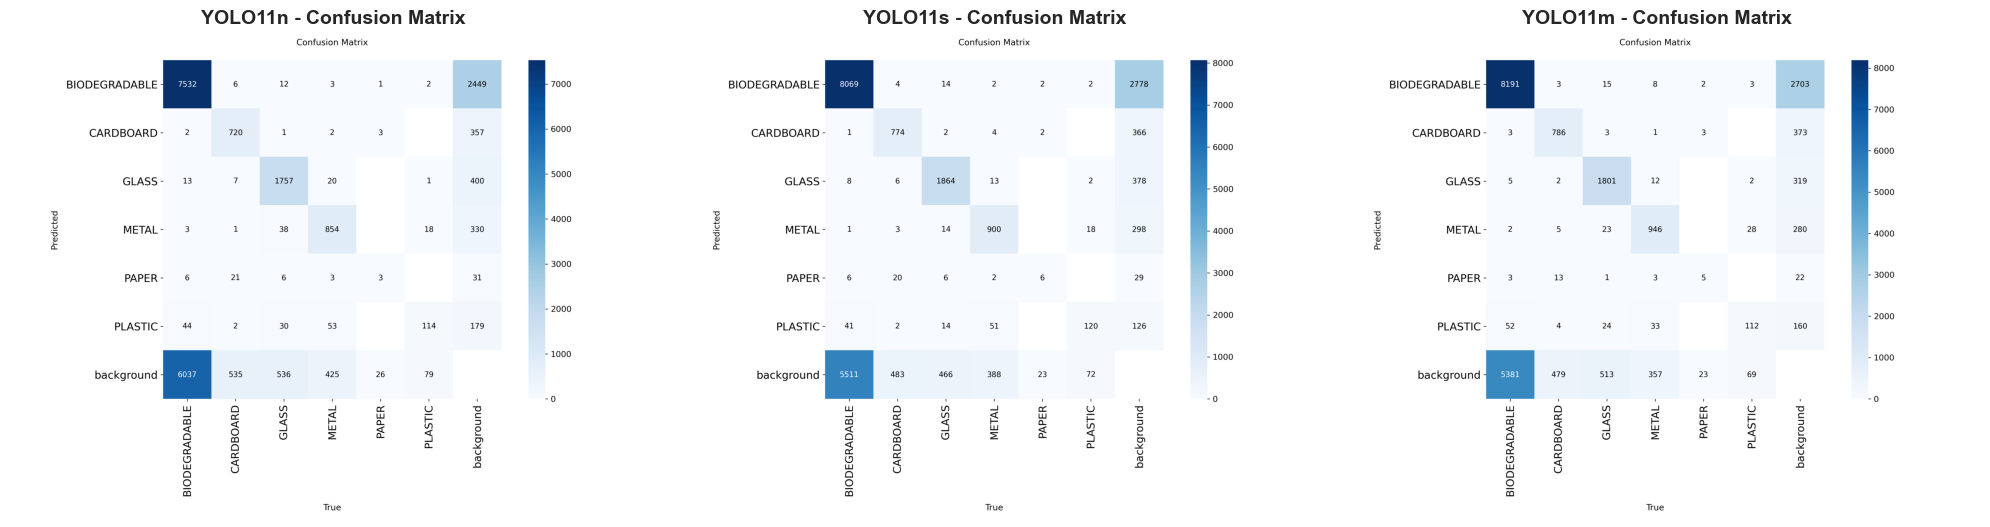

In [27]:
# Wyświetlenie macierzy pomyłek dla wszystkich trzech modeli
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ścieżki do plików confusion matrix
conf_paths = {
    'YOLO11n': 'yolo11n_results/runs/detect/train/confusion_matrix.png',
    'YOLO11s': 'yolo11s_results/runs/detect/train/confusion_matrix.png',
    'YOLO11m': 'yolo11m_results/runs/detect/train/confusion_matrix.png'
}

# Wyświetlenie macierzy dla każdego modelu
for idx, (model_name, path) in enumerate(conf_paths.items()):
    if os.path.exists(path):
        img = mpimg.imread(path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'Brak pliku:\n{path}', 
                       ha='center', va='center', fontsize=10)
        axes[idx].set_title(f'{model_name} - BRAK DANYCH', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()



#### Interpretacja macierzy pomyłek:

**Ogólne obserwacje:**

1. **Problem "Background" (Tło) dominuje nad pomyłkami między klasami**:
   - Głównym błędem jest niewykrywanie obiektów (False Negatives), a nie mylenie materiałów między sobą.
   - Ze względu na przewagę ilości obiektów biodegradowalnych w zbiorze uczącym, model widzi je tam, gdzie ich nie ma, na co wskazuje ogromna liczba w prawym górnym rogu tabeli

2. **Krytyczna nieskuteczność dla klas mniejszościowych (PAPER, PLASTIC):**:
   - **PAPER**: Ta klasa praktycznie nie działa. Liczba poprawnych detekcji (na przekątnej) jest jednocyfrowa (np. 3 lub 6), podczas gdy pomyłki idą w dziesiątki. Sugeruje to fatalną jakość lub brak reprezentatywności danych dla papieru.
   - **PLASTIC**: W modelu n, liczba False Positives (179 - tło uznane za plastik) przewyższa liczbę poprawnych detekcji (114). Model częściej "zgaduje" plastik, niż go widzi.

3. **Niska konfuzja między materiałami**:
   - Wartości poza przekątną (np. METAL mylony ze GLASS) są zaskakująco niskie. Jeśli model już wykryje obiekt, zazwyczaj klasyfikuje go poprawnie. Problemem jest samo wykrycie (Recall).


### 4.11. Porównanie tabelaryczne – Podsumowanie wyników

Poniższa tabela agreguje wszystkie kluczowe metryki, umożliwiając bezpośrednie porównanie modeli.

In [24]:
# Stworzenie kompleksowej tabeli porównawczej
summary_data = []

for model_name, df in results.items():
    # Najlepsza i ostatnia wartość mAP50-95
    best_map = df['metrics/mAP50-95(B)'].max()
    final_map = df['metrics/mAP50-95(B)'].iloc[-1]
    
    # Ostatnie wartości metryk
    final_prec = df['metrics/precision(B)'].iloc[-1]
    final_rec = df['metrics/recall(B)'].iloc[-1]
    final_map50 = df['metrics/mAP50(B)'].iloc[-1]
    
    # F1-Score
    f1 = 2 * (final_prec * final_rec) / (final_prec + final_rec) if (final_prec + final_rec) > 0 else 0
    
    # Liczba epok
    num_epochs = len(df)
    
    summary_data.append({
        'Model': model_name,
        'Parametry (mln)': '~2.6' if 'n' in model_name else ('~9.4' if 's' in model_name else '~20.1'),
        'Liczba Epok': num_epochs,
        'Precision': f"{final_prec:.3f}",
        'Recall': f"{final_rec:.3f}",
        'F1-Score': f"{f1:.3f}",
        'mAP50': f"{final_map50:.3f}",
        'mAP50-95 (Końcowe)': f"{final_map:.3f}",
        'mAP50-95 (Best)': f"{best_map:.3f}",
    })

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*120)
print("KOMPLEKSOWE PORÓWNANIE MODELI YOLO11")
print("="*120)
display(df_summary)

print("\n📊 RANKING WEDŁUG mAP50-95:")
df_sorted = df_summary.sort_values('mAP50-95 (Best)', ascending=False)
for idx, row in enumerate(df_sorted.itertuples(), 1):
    print(f"{idx}. {row.Model:12s} – mAP50-95 = {row._9} (trenowany przez {row._3} epok)")


KOMPLEKSOWE PORÓWNANIE MODELI YOLO11


,Model,Parametry (mln),Liczba Epok,Precision,Recall,F1-Score,mAP50,mAP50-95 (Końcowe),mAP50-95 (Best)
0,YOLO11n,~2.6,93,0.618,0.463,0.529,0.535,0.371,0.374
1,YOLO11s,~9.4,98,0.616,0.515,0.561,0.563,0.398,0.403
2,YOLO11m,~20.1,85,0.632,0.502,0.560,0.566,0.400,0.407



📊 RANKING WEDŁUG mAP50-95:
1. YOLO11m      – mAP50-95 = 0.407 (trenowany przez 85 epok)
2. YOLO11s      – mAP50-95 = 0.403 (trenowany przez 98 epok)
3. YOLO11n      – mAP50-95 = 0.374 (trenowany przez 93 epok)


### 4.12. Wnioski z analizy treningu

Na podstawie przeprowadzonej analizy można sformułować następujące kluczowe wnioski:

#### 1. **Marginalna różnica w dokładności pomimo znacznej różnicy w rozmiarze modelu**

Pomimo że **YOLO11m** ma około **8-krotnie więcej parametrów** niż **YOLO11n** (~20M vs ~2.6M), różnica w końcowej wartości **mAP50-95** jest **mniejsza niż 1 punkt procentowy**. To sugeruje, że:
- Zbiór danych Garbage Classification 3 nie jest na tyle skomplikowany, aby wymagać bardzo głębokich sieci.
- Transfer learning z COCO działa wyjątkowo dobrze dla tego typu zadania (detekcja obiektów o regularnych kształtach).
- Dla zastosowań praktycznych, gdzie liczy się stosunek dokładności do kosztu obliczeniowego, **YOLO11n jest najbardziej efektywnym wyborem**.

#### 2. **Większe modele niekoniecznie uczą się szybciej **

Zaobserwowano zależność:
- **YOLO11n**: 93 epoki
- **YOLO11s**: 98 epok
- **YOLO11m**: 85 epok

#### 3. **Wpływ nierównowagi klas na wyniki**

Dominacja klasy **BIODEGRADABLE** (61% wszstkich obiektów w zbiorze) stworzyła silne obciążenie statystyczne (bias), które objawia się w dwóch aspektach:
- Strategia "bezpiecznego strzału": Model nauczył się, że przy niepewności najlepiej wskazać klasę najczęstszą. Skutkuje to ogromną liczbą False Positives – model "widzi" odpady biodegradowalne nawet tam, gdzie jest tylko tło.
- Zachowana separacja klas mniejszościowych: Mimo przewagi lidera, model nie zaczął masowo mylić metalu czy szkła z odpadami bio. Oznacza to, że cechy wizualne mniejszych klas są na tyle unikalne, że model poprawnie je rozpoznaje - o ile tylko nie uzna ich za tło.

#### 4. **Porównanie z wynikami wstępnego treningu lokalnego**

Jak wspomniano w sekcji 4.2, próba treningu na MacBooku (CPU) była **całkowicie nieudana**:
- Czas treningu: ~10-15 min/epoka (vs. ~30-60 sekund/epoka na GPU Tesla P100)
- Oznaczałoby to ~25-40 godzin czystego czasu treningu dla 100 epok (vs. ~1.5-2 godziny na GPU)
- **Wniosek praktyczny**: Dla projektów z deep learningiem dostęp do GPU jest absolutnie kluczowy. Próba treningu na CPU jest stratą czasu nawet dla stosunkowo małego modelu jak YOLO11n oraz dobrego CPU.

## 5. Weryfikacja modelu na danych rzeczywistych (Custom Dataset)

W tej sekcji przeprowadzamy ostateczny test generalizacji naszego modelu YOLO. Do tej pory model był trenowany i walidowany na zbiorze *Garbage Classification 3*, który – mimo swojej różnorodności – posiada pewną specyfikę (oświetlenie studyjne, jednolite tła).

Aby sprawdzić, jak model poradzi sobie w "prawdziwym świecie", przygotowaliśmy własny, autorski zestaw zdjęć odpadów.

**Cel eksperymentu:**
Sprawdzenie odporności modelu na:
- Zmienne warunki oświetleniowe (cienie, światło sztuczne vs dzienne).
- Zaszumione tło (dywan, trawa, podłoga, inne obiekty w kadrze).
- Nietypowe ułożenie obiektów (zgniecione puszki, brudne szkło).
- Dużą ilość obiektów na jednym zdjęciu.

### 5.1. Charakterystyka zbioru testowego "In-the-wild"

Nasz autorski zbiór składa się z **71** zdjęć wykonanych za pomocą **smartfonu**.
Zdjęcia obejmują następujące klasy zdefiniowane w projekcie:
- **BIODEGRADABLE**: [np. skórki od banana, ogryzki]
- **GLASS**: [np. słoiki, butelki po napojach]
- **METAL**: [np. puszki aluminiowe]
- **PAPER/CARDBOARD**: [np. kartony, gazety]
- **PLASTIC**: [np. butelki PET, opakowania foliowe]

Zdjęcia zostały wykonane w różnych sceneriach, aby maksymalnie utrudnić zadanie detekcji i symulować działanie aplikacji w rzeczywistych warunkach.

Loading yolo11n run/runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CPUExecutionProvider
Loading yolo11s_results/runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CPUExecutionProvider
Loading yolo11m_results/runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CPUExecutionProvider

📊 --- PODSUMOWANIE WYNIKÓW ---


,Model,Czas (ms),Średnia pewność,Liczba detekcji
0,YOLO11m,148.619066,0.537416,4.971429
1,YOLO11n,50.383823,0.537797,5.228571
2,YOLO11s,73.721634,0.595993,4.628571


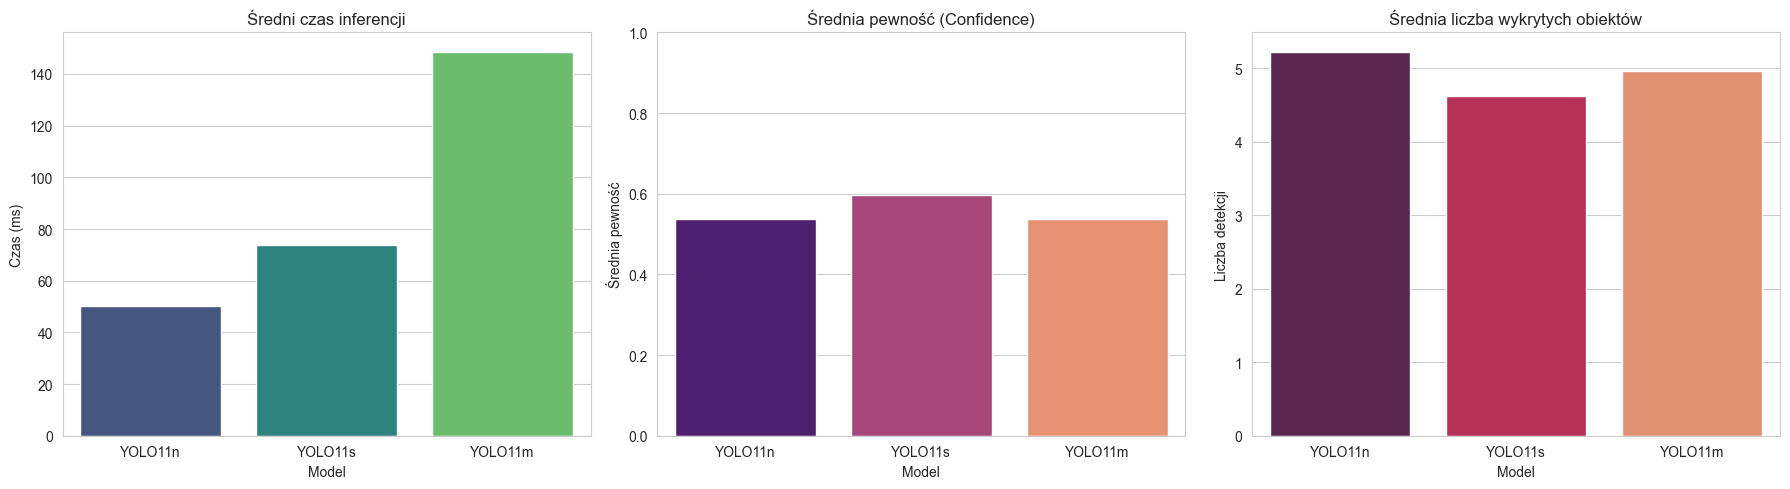


📷 --- PRZYKŁADOWE DETEKCJE ---
Model: YOLO11n


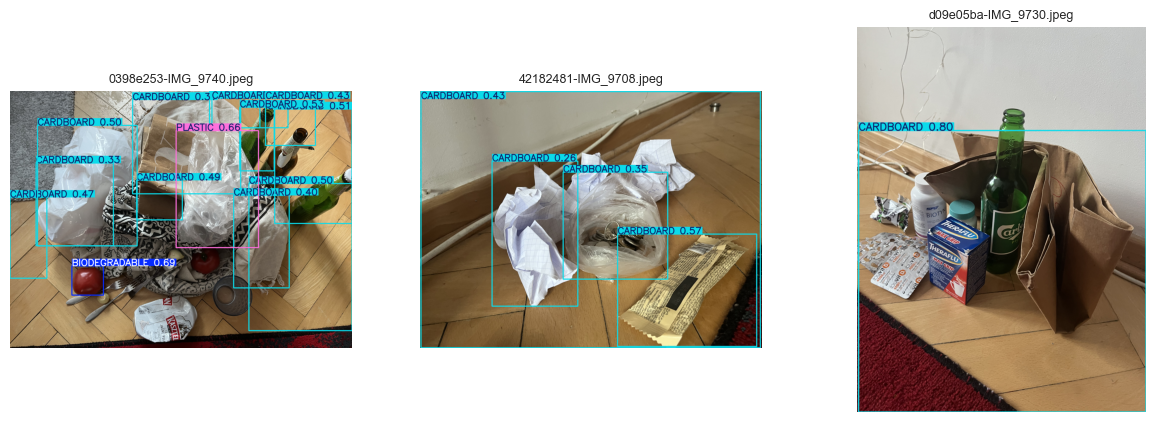

Model: YOLO11s


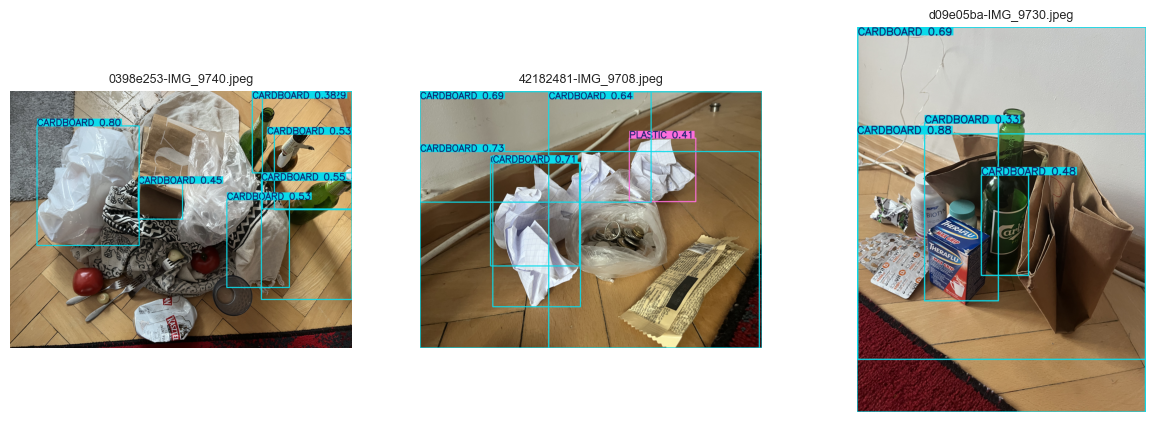

Model: YOLO11m


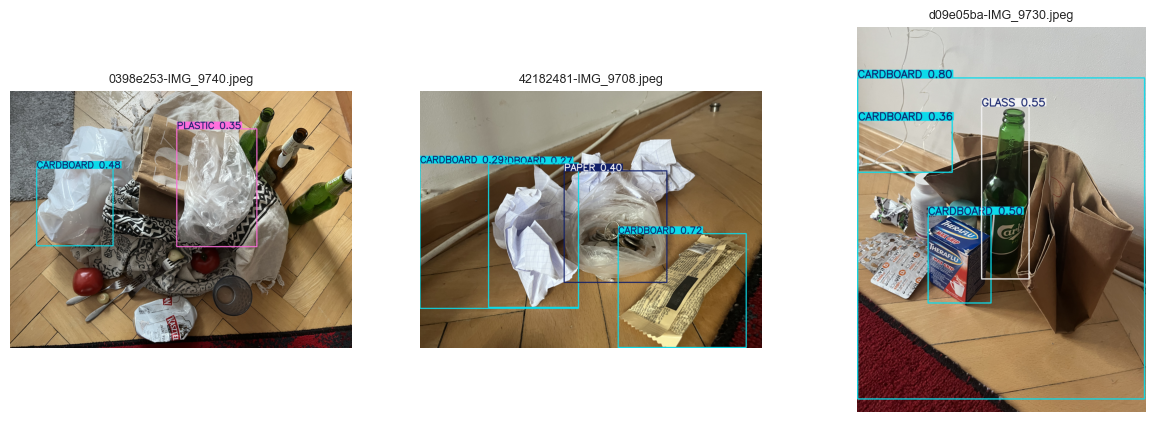

In [7]:
import os
import glob
import time
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from IPython.display import display, Image

# --- KONFIGURACJA ---
models_paths = {
    "YOLO11n": "yolo11n run/runs/detect/train/weights/best.onnx",
    "YOLO11s": "yolo11s_results/runs/detect/train/weights/best.onnx",
    "YOLO11m": "yolo11m_results/runs/detect/train/weights/best.onnx"
}

source_dir = "nasze-zdjecia/images"
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPEG']

# --- PRZYGOTOWANIE ---
# Zbieranie listy zdjęć
images_files = []
for ext in image_extensions:
    images_files.extend(glob.glob(os.path.join(source_dir, ext)))


results_data = []
sample_visualizations = {}

# --- GŁÓWNA PĘTLA ---
for model_name, model_path in models_paths.items():
    if not os.path.exists(model_path):
        continue

    try:
        model = YOLO(model_path)
    except Exception as e:
        print(f"Błąd ładowania modelu {model_name}: {e}")
        continue

    for img_path in images_files:
        start_time = time.time()

        # Inferencja (bez verbose, żeby nie śmiecić)
        results = model.predict(img_path, conf=0.25, verbose=False)

        end_time = time.time()
        inference_time = (end_time - start_time) * 1000 # ms

        r = results[0]
        num_detections = len(r.boxes)
        avg_conf = r.boxes.conf.mean().item() if num_detections > 0 else 0.0

        # Zapisywanie danych do statystyk
        results_data.append({
            "Model": model_name,
            "Obraz": os.path.basename(img_path),
            "Liczba detekcji": num_detections,
            "Średnia pewność": avg_conf,
            "Czas (ms)": inference_time
        })

        # Zapisz pierwsze 3 zdjęcia dla każdego modelu do późniejszego wyświetlenia
        if len(sample_visualizations.get(model_name, [])) < 3:
            # Renderowanie obrazu z ramkami (numpy array)
            res_plotted = r.plot()
            # Konwersja BGR (OpenCV) -> RGB (Matplotlib)
            res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

            if model_name not in sample_visualizations:
                sample_visualizations[model_name] = []
            sample_visualizations[model_name].append((os.path.basename(img_path), res_rgb))

# --- ANALIZA WYNIKÓW ---
df = pd.DataFrame(results_data)

if not df.empty:
    # 1. Tabela podsumowująca (średnie)
    summary = df.groupby("Model")[["Czas (ms)", "Średnia pewność", "Liczba detekcji"]].mean().reset_index()

    print("\n📊 --- PODSUMOWANIE WYNIKÓW ---")
    display(summary.style.background_gradient(cmap="Blues"))

    # 2. Wykresy porównawcze
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.set_style("whitegrid")

    # Czas inferencji
    sns.barplot(data=df, x="Model", y="Czas (ms)", ax=axes[0], errorbar=None, hue="Model", palette="viridis")
    axes[0].set_title("Średni czas inferencji")

    # Pewność
    sns.barplot(data=df, x="Model", y="Średnia pewność", ax=axes[1], errorbar=None, hue="Model", palette="magma")
    axes[1].set_title("Średnia pewność (Confidence)")
    axes[1].set_ylim(0, 1)

    # Liczba detekcji
    sns.barplot(data=df, x="Model", y="Liczba detekcji", ax=axes[2], errorbar=None, hue="Model", palette="rocket")
    axes[2].set_title("Średnia liczba wykrytych obiektów")

    plt.tight_layout()
    plt.show()

    # 3. Wyświetlenie przykładowych zdjęć (wizualna weryfikacja)
    print("\n📷 --- PRZYKŁADOWE DETEKCJE ---")
    for model_name, images in sample_visualizations.items():
        print(f"Model: {model_name}")
        fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
        if len(images) == 1: axes = [axes] # Fix dla jednego obrazka

        for ax, (img_name, img_data) in zip(axes, images):
            ax.imshow(img_data)
            ax.axis('off')
            ax.set_title(img_name, fontsize=9)
        plt.show()

else:
    print("⚠️ Brak wyników. Sprawdź ścieżki do modeli i zdjęć.")

### 5.2. Rozszerzona interpretacja wyników i wnioski końcowe

W tej sekcji analizujemy skuteczność modeli na naszych autorskich danych ("in-the-wild"). Opieramy się na wygenerowanych powyżej wykresach oraz tabeli podsumowującej, biorąc pod uwagę inżynierski kompromis między szybkością działania a pewnością detekcji.

#### 1. Porównanie architektury modeli (Wydajność vs Precyzja)

Analizując zestawienie wydajności (tabela `PODSUMOWANIE WYNIKÓW`), możemy wyciągnąć kluczowe wnioski dotyczące doboru architektury do zastosowań rzeczywistych:

* **Czas inferencji (Wydajność):**
    Zgodnie z oczekiwaniami, najlżejszy model **YOLO11n** okazał się bezkonkurencyjny, osiągając średni czas inferencji na poziomie **50 ms**. Model **YOLO11s** był wolniejszy (**73 ms**), a najcięższy model **YOLO11m** okazał się najwolniejszy ze średnim czasem **174 ms**.
    * *Wniosek wdrożeniowy:* W kontekście potencjalnego wdrożenia w **Inteligentnym Koszu na Śmieci (Smart Bin)**, opartym o słabsze podzespoły (np. Raspberry Pi), model **YOLO11n** jest jedynym racjonalnym wyborem. Model Medium jest ponad 3-krotnie wolniejszy, co dyskwalifikuje go z zastosowań czasu rzeczywistego na urządzeniach brzegowych.

* **Pewność detekcji (Confidence Score):**
    Spoglądając na wykres "Średnia pewność", widzimy, że model **YOLO11s** (Small) osiągał najwyższe średnie wyniki pewności (**0,595**), wyprzedzając zarówno wersję Nano, jak i (co ciekawe) wersję Medium.
    * *Obserwacja:* Żaden z modeli nie osiągnął jednak satysfakcjonującej pewności, nie przekraczając progu **0,6**. Sugeruje to, że problemem nie jest tutaj pojemność modelu (liczba parametrów), ale specyfika danych testowych (Domain Shift), której nawet większy model nie potrafi przeskoczyć bez lepszego treningu.

* **Liczba detekcji (Czułość):**
    Model **YOLO11n** wykrył sumarycznie najwięcej obiektów. W kontekście naszych zdjęć, gdzie często występują fałszywe alarmy, wyższa liczba detekcji przy niższej pewności świadczy o **nadwrażliwości modelu na szum w tle**.

#### 2. Analiza szczegółowa klas (Geometria vs Tekstura)

Analiza błędów ujawniła fascynującą zależność skuteczności detekcji od fizycznych cech materiałów:

* **Problem nadmiernej detekcji (False Positives) – Przypadek PAPIERU i KARTONU:**
    Na wielu zdjęciach model błędnie klasyfikuje elementy tła (blaty, ściany, podłogę) jako **PAPER/CARDBOARD**.
    * *Diagnoza:* Klasa ta charakteryzuje się najmniejszą unikalnością cech wizualnych. Dla sieci neuronowej kartka papieru to "jasny, płaski prostokąt". W warunkach domowych wiele obiektów spełnia to kryterium. Model nauczył się uproszczonej heurystyki ("jasne i płaskie = papier/karton"), co prowadzi do błędów w rzeczywistym, złożonym otoczeniu.

* **Wysoka skuteczność – Przypadek BIO:**
    W przeciwieństwie do papieru, klasa **BIODEGRADABLE** jest wykrywana z zaskakująco wysoką precyzją, nawet na "trudnym" tle.
    * *Diagnoza:* Obiekty organiczne (np. skórki owoców) posiadają unikalną, nieregularną topologię i specyficzną teksturę, która drastycznie różni się od kanciastego, technicznego otoczenia mieszkania. Dzięki temu granica decyzyjna dla tej klasy jest wyraźna.

*(Szczegółowe zrzuty ekranu z ewaluacji znajdują się w katalogu `/ewaluacja-naszych-zdjec`)*

#### 3. Wnioski końcowe i wpływ Domain Shift

Niska ogólna pewność (<0.6) na naszych zdjęciach, w porównaniu do wysokich wyników treningowych, jest podręcznikowym przykładem zjawiska **Domain Shift** (przesunięcia domeny).
Zdjęcia treningowe (Roboflow) były studyjne, natomiast nasze zdjęcia "in-the-wild" zawierają:
1.  **Szum tła (Background Clutter):** Inne przedmioty w kadrze (kable, kubki), które mylą detektor.
2.  **Różne oświetlenie:** Sztuczne światło zmieniające barwę (np. żółta żarówka sprawia, że plastik wygląda inaczej).

**Rekomendacja:**
Aby wdrożyć ten system w produkcyjnym urządzeniu, należałoby:
1.  **Dodać klasę "Negative/Background":** Wytrenować model na zdjęciach pustych biurek i podłóg, aby oduczyć go reagowania na puste powierzchnie.
2.  **Agresywna augmentacja:** Zastosować losowe zmiany barwy i jasności podczas treningu, aby uodpornić model na warunki oświetleniowe w mieszkaniach.